# 타이타닉 생존자 예측 전체 프로젝트

## 1. 데이터 로딩 및 전처리

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 로딩
df = pd.read_csv("Titanic-Dataset.csv")

# 가족 크기 변수 생성
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 객실 등급 추출 (첫 문자)
df["CabinClass"] = df["Cabin"].astype(str).str[0]

# 결측치 처리
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Fare"].fillna(df["Fare"].median(), inplace=True)
df["Embarked"].fillna("S", inplace=True)
df["CabinClass"] = df["CabinClass"].replace("n", "U")  # NaN -> Unknown

# 범주형 인코딩
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked", "CabinClass"], drop_first=True)

# 특성과 타겟 정의
X = df.drop(columns=["Survived", "Name", "Ticket", "Cabin", "PassengerId"])
y = df["Survived"]

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 훈련/검증 분리
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


C:\Users\shjun\AppData\Local\Temp\ipykernel_25628\1293910142.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\shjun\AppData\Local\Temp\ipykernel_25628\1293910142.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

## 2. 기본 모델: 로지스틱 회귀, 결정 트리

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models_basic = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier()
}

for name, model in models_basic.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(y_val, preds):.4f}")
    print(f"F1 Score: {f1_score(y_val, preds):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_val, preds):.4f}")



Logistic Regression
Accuracy: 0.8101
F1 Score: 0.7606
ROC-AUC: 0.7982

Decision Tree
Accuracy: 0.7877
F1 Score: 0.7467
ROC-AUC: 0.7831


## 3. 개선 모델: 랜덤 포레스트, XGBoost

In [3]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models_advanced = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models_advanced.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(y_val, preds):.4f}")
    print(f"F1 Score: {f1_score(y_val, preds):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_val, preds):.4f}")



Random Forest
Accuracy: 0.7877
F1 Score: 0.7361
ROC-AUC: 0.7772

XGBoost
Accuracy: 0.8268
F1 Score: 0.7832
ROC-AUC: 0.8165


C:\Users\shjun\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [15:21:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. 딥러닝 모델 (MLP)

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# GPU 충돌 방지
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0)

loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"MLP Accuracy: {acc:.4f}")


MLP Accuracy: 0.8101


## 5. 학습 시각화 및 평가

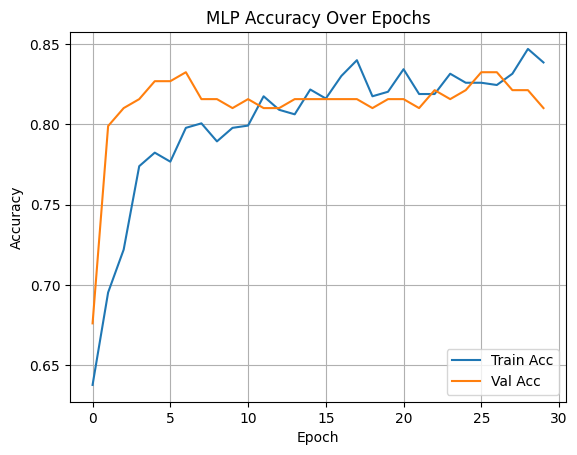

In [5]:
import matplotlib.pyplot as plt

# 학습 곡선
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("MLP Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
